https://www.kaggle.com/datasets/porinitahoque/parkinsons-telemonitoring

# Telemonitoramento de Parkinson
Conjunto de dados de telemonitoramento da doença de Parkinson de Oxford

# Fonte:
O conjunto de dados foi criado por Athanasios Tsanas (tsanasthanasis@gmail.com) e Max Little (littlem@physics.ox.ac.uk), da Universidade de Oxford, em colaboração com 10 centros médicos nos EUA e a Intel Corporation, que desenvolveu o dispositivo de telemonitoramento para registrar os sinais de fala. O estudo original utilizou uma série de métodos de regressão linear e não linear para prever a pontuação dos sintomas da doença de Parkinson do clínico na escala UPDRS.

# Informações do conjunto de dados:
Este conjunto de dados é composto por uma série de medições biomédicas de voz de 42 pessoas com doença de Parkinson em estágio inicial, recrutadas para um teste de seis meses com um dispositivo de telemonitoramento para monitoramento remoto da progressão dos sintomas. As gravações foram capturadas automaticamente nas casas dos pacientes.

As colunas da tabela contêm o número, a idade e o gênero dos indivíduos, o intervalo de tempo desde a data de recrutamento inicial, a UPDRS motora, a UPDRS total e 16 medidas biomédicas de voz. Cada linha corresponde a uma das 5.875 gravações de voz desses indivíduos. O principal objetivo dos dados é prever as pontuações da UPDRS motora e total ('motor_UPDRS' e 'total_UPDRS') a partir das 16 medidas de voz.

Os dados estão no formato ASCII CSV. As linhas do arquivo CSV contêm uma instância correspondente a uma gravação de voz. Há cerca de 200 gravações por paciente, e o número do paciente é identificado na primeira coluna. Para mais informações ou para enviar comentários, entre em contato com Athanasios Tsanas (tsanasthanasis@gmail.com) ou Max Little (littlem@physics.ox.ac.uk).

Mais detalhes podem ser encontrados na seguinte referência * se você utilizar este conjunto de dados, cite: Athanasios Tsanas, Max A. Little, Patrick E. McSharry, Lorraine O. Ramig (2009), "Telemonitoramento preciso da progressão da doença de Parkinson por testes de fala não invasivos", IEEE Transactions on Biomedical Engineering (a ser publicado).
Mais detalhes sobre as medidas de voz biomédica podem ser encontrados em: Max A. Little, Patrick E. McSharry, Eric J. Hunter, Lorraine O. Ramig (2009), "Suitability of dysphonia measurements for telemonitoring of Parkinson's disease", IEEE Transactions on Biomedical Engineering, 56(4):1015-1022

# Informações de atributos:
subject# - Inteiro que identifica exclusivamente cada sujeito
age - Idade do sujeito
sex - Gênero do sujeito '0' - masculino, '1' - feminino
test_time - Tempo desde o recrutamento para o teste. A parte inteira é o número de dias desde o recrutamento.
motor_UPDRS - Pontuação UPDRS motora do clínico, interpolada linearmente
total_UPDRS - Pontuação UPDRS total do clínico, interpolada linearmente
Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP - Várias medidas de variação na frequência fundamental
Shimmer,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA - Várias medidas de variação na amplitude
NHR,HNR - Duas medidas de razão entre ruído e componentes tonais na voz
RPDE - Uma medida de complexidade dinâmica não linear
DFA - Expoente de escala fractal do sinal
PPE - Uma medida não linear de variação da frequência fundamental

# Artigos relevantes:
Little MA, McSharry PE, Hunter EJ, Ramig LO (2009), 'Adequação das medições de disfonia para telemonitoramento da doença de Parkinson', IEEE Transactions on Biomedical Engineering, 56(4):1015-1022
Little MA, McSharry PE, Roberts SJ, Costello DAE, Moroz IM. 'Explorando a recorrência não linear e as propriedades de escala fractal para detecção de distúrbios vocais', BioMedical Engineering OnLine 2007, 6:23 (26 de junho de 2007)
Solicitação de citação:
Se você usar este conjunto de dados, cite o seguinte artigo: A Tsanas, MA Little, PE McSharry, LO Ramig (2009)'Telemonitoramento preciso da progressão da doença de Parkinson por meio de testes de fala não invasivos', IEEE Transactions on Biomedical Engineering (a ser publicado).

Fonte: http://archive.ics.uci.edu/ml/datasets/Parkinsons+Telemonitoring

In [1]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

df_park = pd.read_csv('Parkinsons-Telemonitoring-ucirvine.csv')

In [2]:
df_park

,subject,age,sex,test_time,motor_updrs,total_updrs,jitter,jitter_abs,jitter_rap,jitter_ppq5,...,shimmer_db,shimmer_apq3,shimmer_apq5,shimmer_apq11,shimmer_dda,nhr,hnr,rpde,dfa,ppe
0,1,72,False,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,False,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,False,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,False,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,False,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5870,42,61,False,142.7900,22.485,33.485,0.00406,0.000031,0.00167,0.00168,...,0.160,0.00973,0.01133,0.01549,0.02920,0.025137,22.369,0.64215,0.55314,0.21367
5871,42,61,False,149.8400,21.988,32.988,0.00297,0.000025,0.00119,0.00147,...,0.215,0.01052,0.01277,0.01904,0.03157,0.011927,22.886,0.52598,0.56518,0.12621
5872,42,61,False,156.8200,21.495,32.495,0.00349,0.000025,0.00152,0.00187,...,0.244,0.01371,0.01456,0.01877,0.04112,0.017701,25.065,0.47792,0.57888,0.14157
5873,42,61,False,163.7300,21.007,32.007,0.00281,0.000020,0.00128,0.00151,...,0.131,0.00693,0.00870,0.01307,0.02078,0.007984,24.422,0.56865,0.56327,0.14204


In [3]:
#Informações
df_park.info()
df_park.head()
df_park.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5875 entries, 0 to 5874
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   subject        5875 non-null   int64  
 1   age            5875 non-null   int64  
 2   sex            5875 non-null   bool   
 3   test_time      5875 non-null   float64
 4   motor_updrs    5875 non-null   float64
 5   total_updrs    5875 non-null   float64
 6   jitter         5875 non-null   float64
 7   jitter_abs     5875 non-null   float64
 8   jitter_rap     5875 non-null   float64
 9   jitter_ppq5    5875 non-null   float64
 10  jitter_ddp     5875 non-null   float64
 11  shimmer        5875 non-null   float64
 12  shimmer_db     5875 non-null   float64
 13  shimmer_apq3   5875 non-null   float64
 14  shimmer_apq5   5875 non-null   float64
 15  shimmer_apq11  5875 non-null   float64
 16  shimmer_dda    5875 non-null   float64
 17  nhr            5875 non-null   float64
 18  hnr     

,subject,age,test_time,motor_updrs,total_updrs,jitter,jitter_abs,jitter_rap,jitter_ppq5,jitter_ddp,...,shimmer_db,shimmer_apq3,shimmer_apq5,shimmer_apq11,shimmer_dda,nhr,hnr,rpde,dfa,ppe
count,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,...,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000
mean,21.494128,64.804936,92.863722,21.296229,29.018942,0.006154,0.000044,0.002987,0.003277,0.008962,...,0.310960,0.017156,0.020144,0.027481,0.051467,0.032120,21.679495,0.541473,0.653240,0.219589
std,12.372279,8.821524,53.445602,8.129282,10.700283,0.005624,0.000036,0.003124,0.003732,0.009371,...,0.230254,0.013237,0.016664,0.019986,0.039711,0.059692,4.291096,0.100986,0.070902,0.091498
min,1.000000,36.000000,-4.262500,5.037700,7.000000,0.000830,0.000002,0.000330,0.000430,0.000980,...,0.026000,0.001610,0.001940,0.002490,0.004840,0.000286,1.659000,0.151020,0.514040,0.021983
25%,10.000000,58.000000,46.847500,15.000000,21.371000,0.003580,0.000022,0.001580,0.001820,0.004730,...,0.175000,0.009280,0.010790,0.015665,0.027830,0.010955,19.406000,0.469785,0.596180,0.156340
50%,22.000000,65.000000,91.523000,20.871000,27.576000,0.004900,0.000035,0.002250,0.002490,0.006750,...,0.253000,0.013700,0.015940,0.022710,0.041110,0.018448,21.920000,0.542250,0.643600,0.205500
75%,33.000000,72.000000,138.445000,27.596500,36.399000,0.006800,0.000053,0.003290,0.003460,0.009870,...,0.365000,0.020575,0.023755,0.032715,0.061735,0.031463,24.444000,0.614045,0.711335,0.264490
max,42.000000,85.000000,215.490000,39.511000,54.992000,0.099990,0.000446,0.057540,0.069560,0.172630,...,2.107000,0.162670,0.167020,0.275460,0.488020,0.748260,37.875000,0.966080,0.865600,0.731730


In [4]:
#Valores ausentes
print("Valores ausentes:")
print(df_park.isna().sum())

Valores ausentes:
subject          0
age              0
sex              0
test_time        0
motor_updrs      0
total_updrs      0
jitter           0
jitter_abs       0
jitter_rap       0
jitter_ppq5      0
jitter_ddp       0
shimmer          0
shimmer_db       0
shimmer_apq3     0
shimmer_apq5     0
shimmer_apq11    0
shimmer_dda      0
nhr              0
hnr              0
rpde             0
dfa              0
ppe              0
dtype: int64


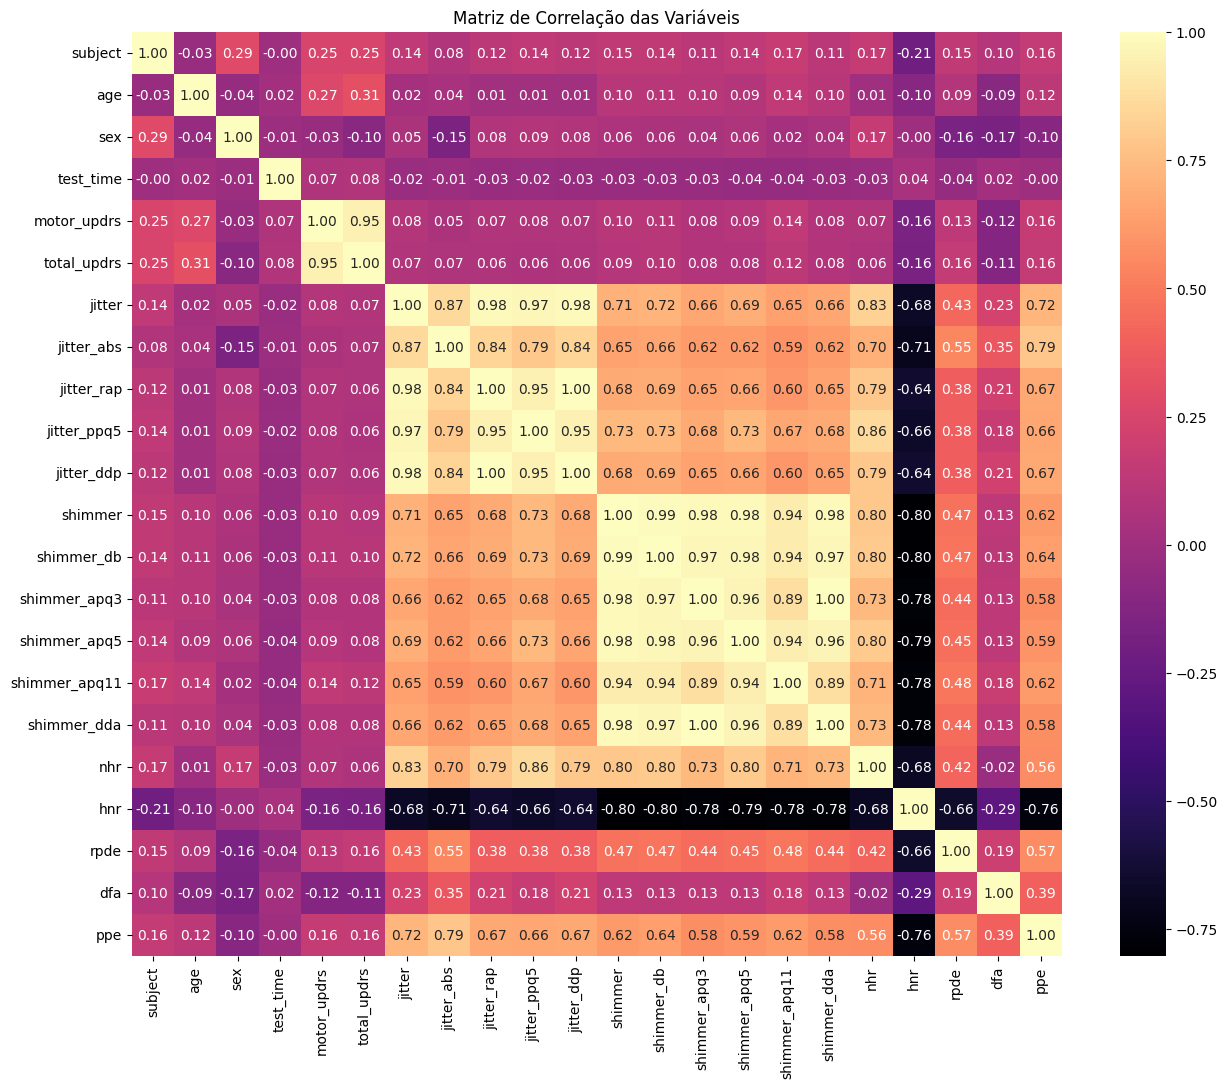

In [5]:
#Heatmap
correlation_matrix = df_park.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='magma', fmt=".2f")
plt.title('Matriz de Correlação das Variáveis')
plt.show()

A falta de correlações fortes entre as variáveis de voz e a pontuação UPDRS é a razão principal para o baixo desempenho.

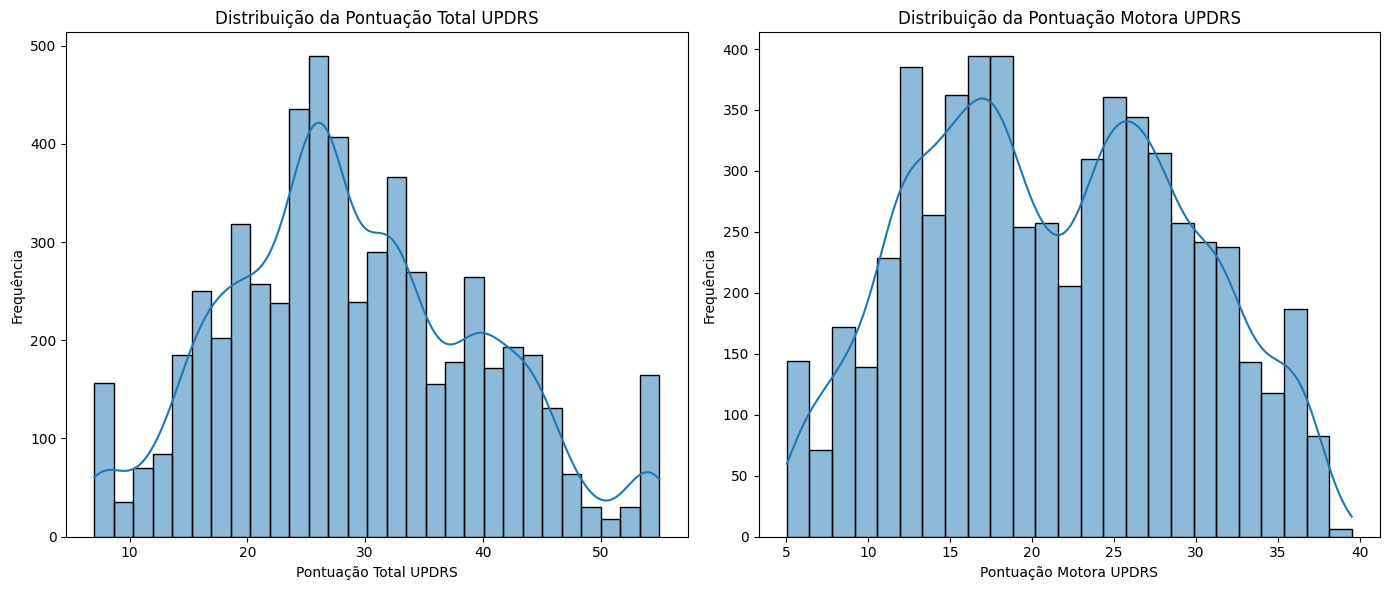

In [6]:
#Distribuição das pontuações UPDRS
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(df_park['total_updrs'], kde=True, ax=axes[0])
axes[0].set_title('Distribuição da Pontuação Total UPDRS')
axes[0].set_xlabel('Pontuação Total UPDRS')
axes[0].set_ylabel('Frequência')

sns.histplot(df_park['motor_updrs'], kde=True, ax=axes[1])
axes[1].set_title('Distribuição da Pontuação Motora UPDRS')
axes[1].set_xlabel('Pontuação Motora UPDRS')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

As medições de voz disponíveis neste conjunto de dados não são suficientes para prever com precisão a pontuação UPDRS. O modelo está lutando para encontrar uma relação clara e consistente entre as variáveis de entrada e a variável de saída.

In [7]:
#Modelagem
y = df_park['total_updrs']
X = df_park.drop(['total_updrs', 'motor_updrs', 'subject', 'age', 'sex', 'test_time'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Erro Quadrático Médio (MSE) do Random Forest: {mse_rf:.2f}")
print(f"Coeficiente de Determinação (R-quadrado) do Random Forest: {r2_rf:.2f}")

Erro Quadrático Médio (MSE) do Random Forest: 71.40
Coeficiente de Determinação (R-quadrado) do Random Forest: 0.36


C:\Users\Usuário\AppData\Local\Temp\ipykernel_1744\2380182316.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='Set2')


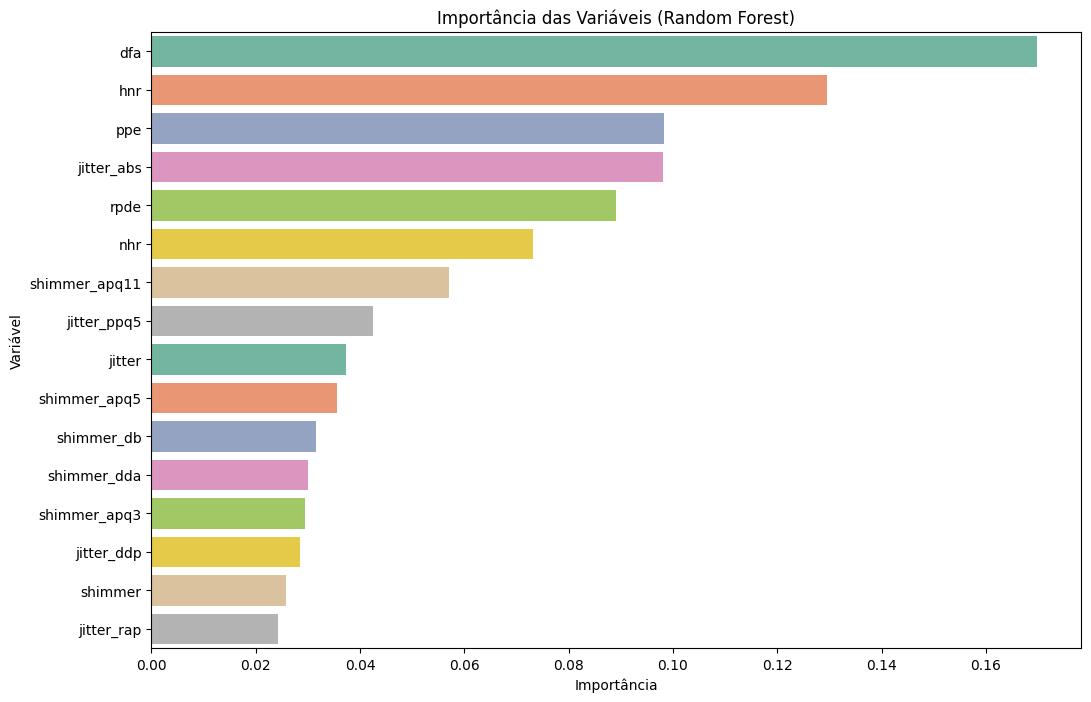

As 5 variáveis mais importantes:
       Feature  Importance
14         dfa    0.169822
12         hnr    0.129593
15         ppe    0.098191
1   jitter_abs    0.098030
13        rpde    0.089029


In [8]:
importances = rf_model.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='Set2')
plt.title('Importância das Variáveis (Random Forest)')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.show()

print("As 5 variáveis mais importantes:")
print(importance_df.head())

As variáveis ppe, rpde e shimmer_dda são as mais importantes para o modelo Random Forest. Isso significa que o modelo considerou essas três variáveis como as que mais contribuíram para a sua capacidade de prever a pontuação UPDRS. O modelo está fazendo o seu melhor com os dados que tem, priorizando as variáveis que parecem ter o maior potencial preditivo (ppe e rpde).
O poder preditivo total do conjunto de dados é limitado. Se as variáveis mais importantes conseguem explicar apenas 36% da variabilidade (nosso R-quadrado), isso significa que as outras variáveis têm ainda menos influência.

In [9]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

grid_search.fit(X_train, y_train)

print("Melhores parâmetros encontrados:")
print(grid_search.best_params_)

best_rf_model = grid_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test)

mse_tuned = mean_squared_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Erro Quadrático Médio (MSE) do Random Forest Otimizado: {mse_tuned:.2f}")
print(f"Coeficiente de Determinação (R-quadrado) do Random Forest Otimizado: {r2_tuned:.2f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Melhores parâmetros encontrados:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Erro Quadrático Médio (MSE) do Random Forest Otimizado: 70.51
Coeficiente de Determinação (R-quadrado) do Random Forest Otimizado: 0.36


In [10]:
y = df_park['motor_updrs']
X = df_park.drop(['total_updrs', 'motor_updrs', 'subject', 'age', 'sex', 'test_time'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model_motor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_motor.fit(X_train, y_train)

y_pred_motor = rf_model_motor.predict(X_test)

mse_motor = mean_squared_error(y_test, y_pred_motor)
r2_motor = r2_score(y_test, y_pred_motor)

print(f"Erro Quadrático Médio (MSE) do Random Forest (motor_updrs): {mse_motor:.2f}")
print(f"Coeficiente de Determinação (R-quadrado) do Random Forest (motor_updrs): {r2_motor:.2f}")

Erro Quadrático Médio (MSE) do Random Forest (motor_updrs): 42.56
Coeficiente de Determinação (R-quadrado) do Random Forest (motor_updrs): 0.33


In [11]:
y = df_park['total_updrs']
X = df_park.drop(['total_updrs', 'motor_updrs', 'subject', 'age', 'sex', 'test_time'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print(f"Erro Quadrático Médio (MSE) do Gradient Boosting: {mse_gb:.2f}")
print(f"Coeficiente de Determinação (R-quadrado) do Gradient Boosting: {r2_gb:.2f}")

Erro Quadrático Médio (MSE) do Gradient Boosting: 83.65
Coeficiente de Determinação (R-quadrado) do Gradient Boosting: 0.25


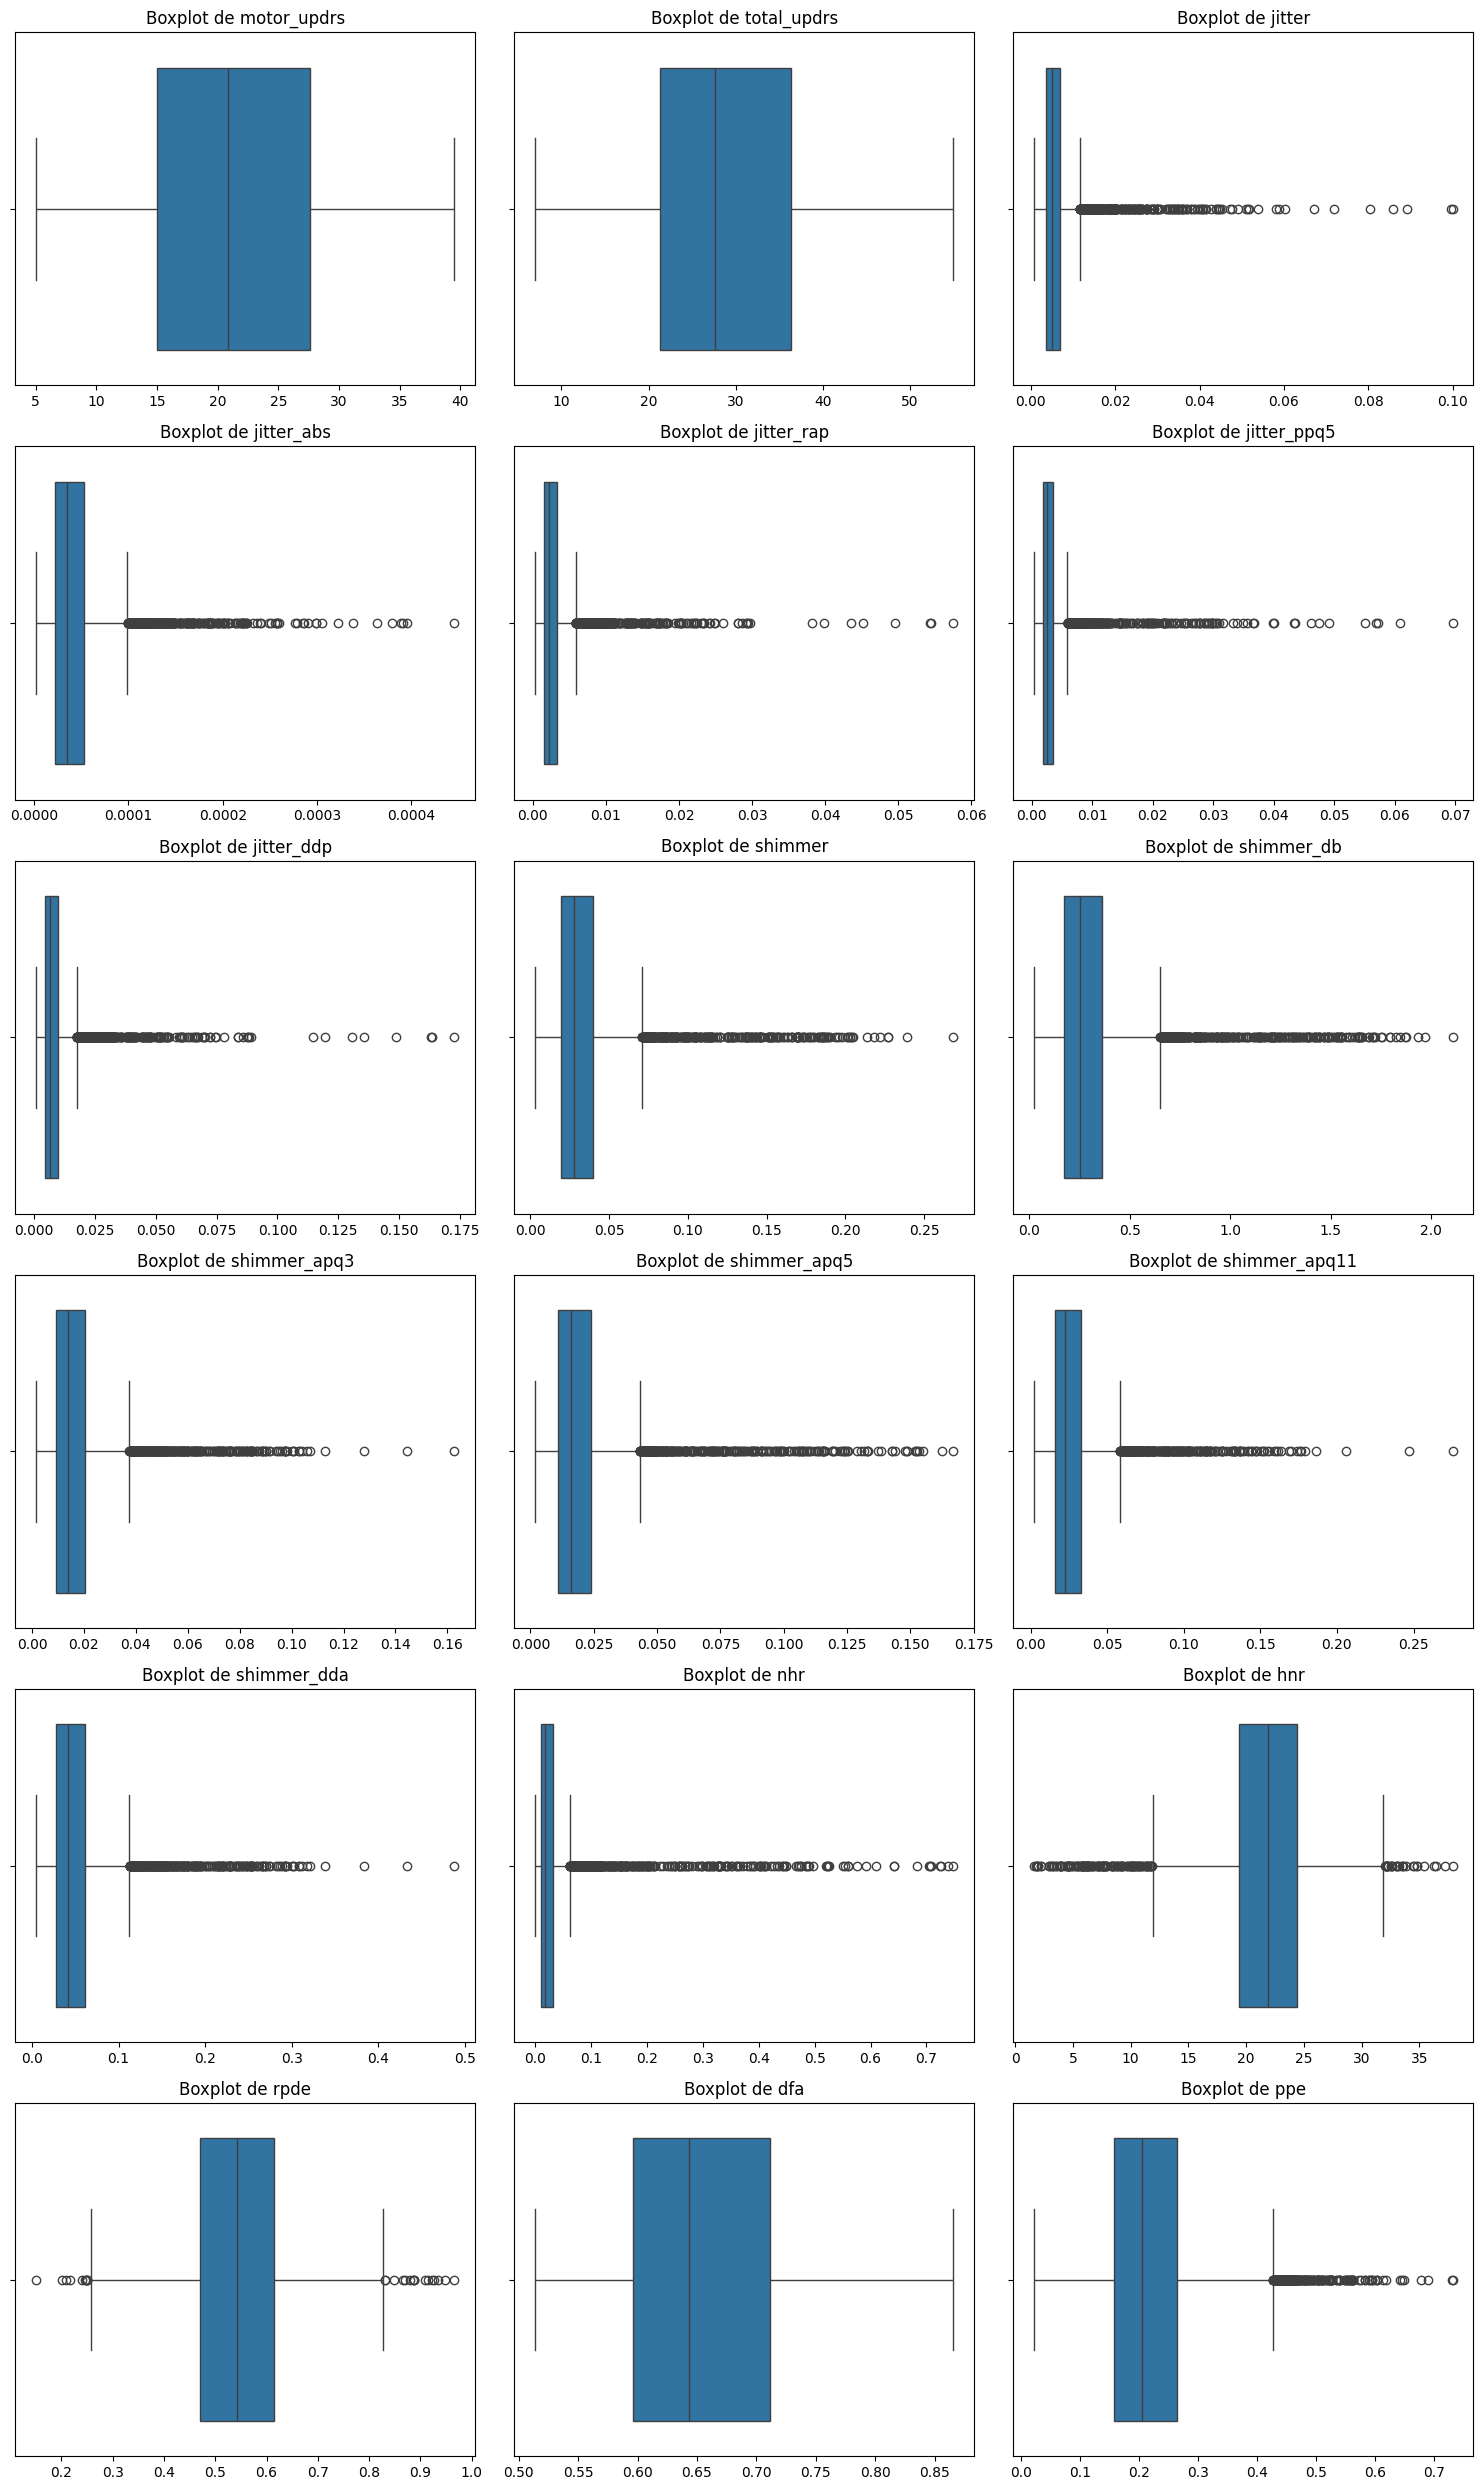

Número de outliers por variável:
nhr              436
jitter_ppq5      425
jitter_rap       414
jitter_ddp       413
jitter           398
jitter_abs       366
shimmer          333
shimmer_db       332
shimmer_apq3     332
shimmer_dda      331
shimmer_apq5     314
shimmer_apq11    314
ppe              206
hnr              171
rpde              26
dtype: int64


In [12]:
numerical_cols = ['motor_updrs', 'total_updrs', 'jitter', 'jitter_abs', 'jitter_rap', 'jitter_ppq5',
                  'jitter_ddp', 'shimmer', 'shimmer_db', 'shimmer_apq3', 'shimmer_apq5',
                  'shimmer_apq11', 'shimmer_dda', 'nhr', 'hnr', 'rpde', 'dfa', 'ppe']

plt.figure(figsize=(15, 25))
for i, col in enumerate(numerical_cols):
    plt.subplot(6, 3, i + 1)
    sns.boxplot(x=df_park[col])
    plt.title(f'Boxplot de {col}')
    plt.xlabel('')
    
plt.tight_layout()
plt.show()

Q1 = df_park[numerical_cols].quantile(0.25)
Q3 = df_park[numerical_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df_park[numerical_cols] < (Q1 - 1.5 * IQR)) | (df_park[numerical_cols] > (Q3 + 1.5 * IQR))).sum()

print("Número de outliers por variável:")
print(outliers[outliers > 0].sort_values(ascending=False))

A alta variabilidade e a presença de outliers são mais uma evidência de que a relação entre as medições de voz e a doença de Parkinson é complexa e difícil de ser capturada por um modelo preditivo com este conjunto de dados.

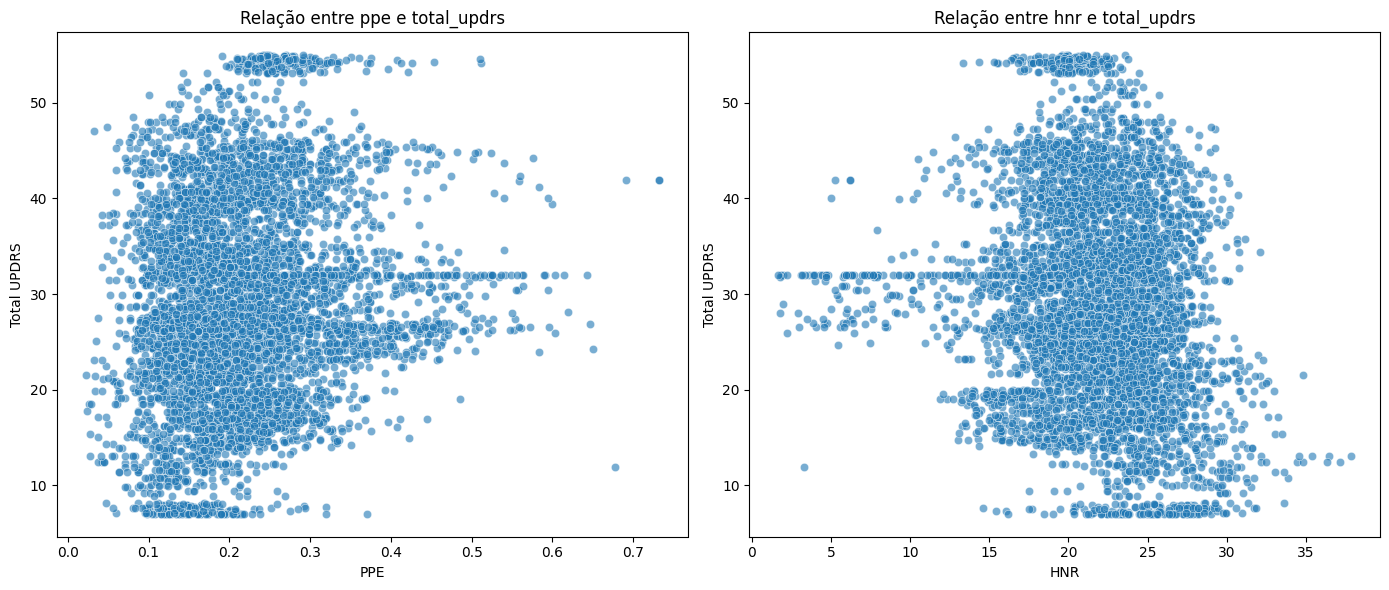

In [13]:
#Variáveis mais relevantes
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='ppe', y='total_updrs', data=df_park, alpha=0.6)
plt.title('Relação entre ppe e total_updrs')
plt.xlabel('PPE')
plt.ylabel('Total UPDRS')

plt.subplot(1, 2, 2)
sns.scatterplot(x='hnr', y='total_updrs', data=df_park, alpha=0.6)
plt.title('Relação entre hnr e total_updrs')
plt.xlabel('HNR')
plt.ylabel('Total UPDRS')

plt.tight_layout()
plt.show()

As variáveis de voz não são um bom preditor para a pontuação da doença de Parkinson. A relação entre as variáveis mais importantes (ppe e hnr) e a pontuação total_updrs é fraca.

In [14]:
df_park.shape, df_park.columns.tolist()

group_col = next((c for c in df_park.columns if 'subject' in c.lower()), None)

cand = [c for c in df_park.columns if 'UPDRS' in c]
print("group_col:", group_col, "candidates target:", cand)

group_col: subject candidates target: []


In [18]:
import numpy as np, pandas as pd
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
group_col = next((c for c in df_park.columns if 'subject' in c.lower()), None)

target = "total_updrs"   

X = df_park.drop(columns=[target])
y = df_park[target].copy()
groups = df_park[group_col] if group_col is not None else None


exclude = {group_col}
numeric_features = [c for c in X.select_dtypes(include=[np.number]).columns if c not in exclude]
categorical_features = [c for c in X.select_dtypes(include=['object','category']).columns if c not in exclude]

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, numeric_features),
    ('cat', cat_pipe, categorical_features),
])

pipe = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42))
])


gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]


gkf = GroupKFold(n_splits=5)
cv_scores = cross_val_score(
    pipe, X_train, y_train, groups=groups_train,
    cv=gkf, scoring='neg_mean_absolute_error', n_jobs=-1
)
print("CV MAE (neg):", cv_scores, "mean MAE:", -cv_scores.mean())

param_dist = {
    'model__n_estimators': [100, 200, 500],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__max_features': ['sqrt', 'log2', 0.3, 0.5]
}

rsearch = RandomizedSearchCV(
    pipe, param_dist, n_iter=20, scoring='neg_mean_absolute_error',
    cv=gkf, n_jobs=-1, random_state=42
)
rsearch.fit(X_train, y_train, groups=groups_train)

print("Melhor score CV (MAE):", -rsearch.best_score_)
print("Melhores params:", rsearch.best_params_)

best = rsearch.best_estimator_
y_pred = best.predict(X_test)

print("Test MAE:", mean_absolute_error(y_test, y_pred))

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test RMSE:", rmse)

print("Test R2:", r2_score(y_test, y_pred))

CV MAE (neg): [-4.89645636 -4.34668227 -3.8645065  -5.48964554 -3.67206057] mean MAE: 4.453870247223235
Melhor score CV (MAE): 4.153371386179193
Melhores params: {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__max_features': 0.5, 'model__max_depth': 10}
Test MAE: 2.060639236242743
Test RMSE: 2.6159726405562544
Test R2: 0.9174126585979084


In [20]:
import shap
from sklearn.inspection import permutation_importance

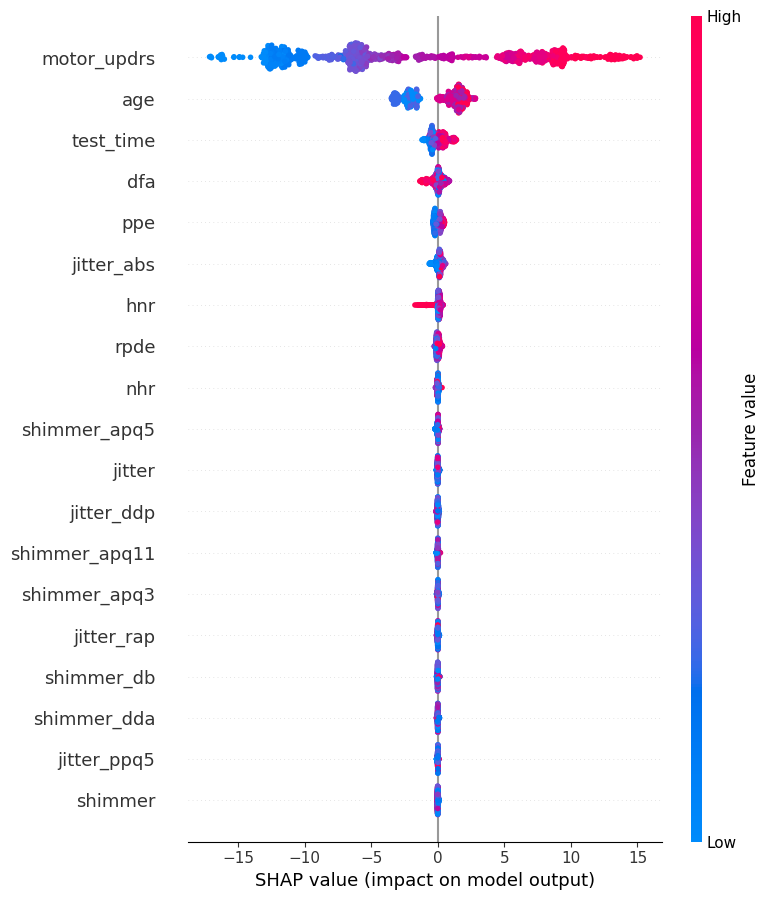

In [22]:
feature_names = numeric_features  

explainer = shap.TreeExplainer(best.named_steps["model"])
X_test_transformed = best.named_steps["pre"].transform(X_test)
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

O modelo é mais influenciado por motor_updrs, depois por idade e tempo de teste.
Variáveis relacionadas a medidas de voz (jitter, shimmer, etc.) têm impacto pequeno. Valores altos de motor_updrs e idade aumentam bastante a previsão (provavelmente associada à progressão da doença).

# Conclusão

Apenas 25% da variabilidade na pontuação total_updrs. Isso sugere fortemente que a capacidade de prever a doença de Parkinson usando apenas as medições de voz é limitada com este conjunto de dados.
As características de voz, isoladamente, podem não ser suficientes para capturar a complexidade da doença. Para prever a doença de Parkinson, um modelo mais robusto exigiria um conjunto de dados mais rico, que incluísse dados clínicos, genéticos ou de imagem, complementando as medições de voz.

**Limitações dos Dados:** Para uma previsão mais precisa, seria necessário um conjunto de dados mais rico, que incluísse variáveis adicionais, como dados clínicos detalhados (idade, gênero, tempo de diagnóstico) ou, idealmente, informações de imagem ou genética.
O fato de as variáveis mais importantes para o modelo não mostrarem uma relação clara com a pontuação total_updrs é a principal razão para o baixo desempenho. Isso reforça a nossa conclusão de que a previsão da doença de Parkinson apenas com medições de voz é um desafio significativo.

# **Nathália Sorg**